# Метрики классификатора на бенчмарках

Небольшой ноутбук: считает метрики image-классификатора на трёх наборах.

- **UnsafeBench** (Safe + Unsafe) → полные метрики: accuracy / precision / recall / FPR / ROC AUC.
- **yesidobyte/nsfw1024** (всё NSFW) → recall (доля пойманных).
- **wallstoneai/civitai-...** (всё NSFW, сгенерировано ИИ) → recall.

По умолчанию — на сабсете **100 картинок** на набор. Внизу — простые иллюстративные графики.

> Классификатор настоящий: `censor_guard.evaluation.ImageClassifierRunner`.
> Внешние NSFW-датасеты требуют `HF_TOKEN` (env или `huggingface-cli login`).

## 0. Настройки

In [1]:
import os
# Размер сабсета на каждый набор (можно начать со 100). Переопределяется env-переменной.
N_PER_DATASET = int(os.environ.get("N_PER_DATASET", "100"))
MAX_LOAD_SECONDS = 600   # тайм-бюджет на стриминг одного внешнего набора
SEED = 42
print("N_PER_DATASET =", N_PER_DATASET)

N_PER_DATASET = 100


## 1. Подготовка

In [2]:
import sys, time, random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

os.environ.setdefault("HF_HUB_DOWNLOAD_TIMEOUT", "30")
from huggingface_hub import get_token as _hf_get_token
HF_TOKEN = os.environ.get("HF_TOKEN") or _hf_get_token()
print("HF_TOKEN:", "найден" if HF_TOKEN else "НЕ найден (внешние NSFW пропустятся)")

from censor_guard.evaluation import ImageClassifierRunner
random.seed(SEED); np.random.seed(SEED)
plt.rcParams["figure.dpi"] = 110

runner = ImageClassifierRunner()
print("Пороги: block >=", runner.settings.block_threshold, "| review >=", runner.settings.review_threshold)

HF_TOKEN: найден
Пороги: block >= 0.85 | review >= 0.55


In [3]:
from datasets import load_dataset

UB = load_dataset("yiting/UnsafeBench")["test"]
print("UnsafeBench:", UB.num_rows, "строк")

UnsafeBench: 2037 строк


## 2. Прогон и метрики

Один прогон = вердикт `allow/review/block`. Считаем `flagged = review|block`
(картинка помечена небезопасной) и непрерывную `unsafe_score` для ROC.

In [4]:
from tqdm.auto import tqdm


def run_images(images_with_labels, tag):
    """images_with_labels: список (PIL.Image, true_unsafe: bool|None). -> DataFrame."""
    rows = []
    for img, true_unsafe in tqdm(images_with_labels, desc=f"classify · {tag}", unit="img"):
        res = runner.classify(img)
        rows.append({
            "dataset": tag,
            "true_unsafe": true_unsafe,
            "flagged": res.flagged,
            "unsafe_score": res.unsafe_score,
            "nsfw": res.signal_scores.get("explicit_content_detector", {}).get("sexual", 0.0),
        })
    return pd.DataFrame(rows)


def load_ub_balanced(n):
    """n картинок из UnsafeBench, поровну Safe/Unsafe. -> [(image, true_unsafe)]."""
    labels = UB["safety_label"]
    half = n // 2
    out = []
    for lab, want in (("Unsafe", n - half), ("Safe", half)):
        idxs = [i for i, l in enumerate(labels) if l == lab]
        random.Random(SEED).shuffle(idxs)
        pbar = tqdm(total=want, desc=f"load UnsafeBench · {lab}", unit="img")
        got = 0
        for i in idxs:
            try:
                out.append((UB[i]["image"].convert("RGB"), lab == "Unsafe"))
            except Exception:
                continue
            got += 1
            pbar.update(1)
            if got >= want:
                break
        pbar.close()
    random.Random(SEED).shuffle(out)
    return out


def load_nsfw_stream(name, n, max_retries=5):
    """n NSFW-картинок стримингом (все unsafe). -> [(image, True)].

    Устойчив к сетевым обрывам (Broken pipe и т.п.): при ошибке делает повтор,
    докачивая поток через .skip(len(out)) — без дубликатов уже собранного.
    """
    if not HF_TOKEN:
        print(f"  [{name}] пропущен: нет HF_TOKEN")
        return []
    out, t0 = [], time.time()
    pbar = tqdm(total=n, desc=name.split("/")[-1][:28], unit="img")
    attempt = 0
    while len(out) < n and attempt <= max_retries and time.time() - t0 < MAX_LOAD_SECONDS:
        attempt += 1
        try:
            ds = load_dataset(name, split="train", streaming=True, token=HF_TOKEN)
            if out:
                ds = ds.skip(len(out))   # докачиваем с места обрыва
            for ex in ds:
                if time.time() - t0 > MAX_LOAD_SECONDS:
                    tqdm.write(f"  [{name}] тайм-бюджет исчерпан, взято {len(out)}")
                    break
                img = ex.get("image")
                if img is None:
                    continue
                try:
                    out.append((img.convert("RGB"), True))
                except Exception:
                    continue
                pbar.update(1)
                if len(out) >= n:
                    break
            break  # без исключения: достигли n / тайм-бюджета / поток исчерпан
        except Exception as e:
            pbar.set_postfix_str(f"retry {attempt}/{max_retries}")
            tqdm.write(f"  [{name}] попытка {attempt}: {type(e).__name__}: {str(e)[:60]} — повтор")
            time.sleep(3)
    pbar.close()
    print(f"  [{name}] загружено {len(out)} за {time.time()-t0:.0f}s (попыток: {attempt})")
    return out


def binary_metrics(df):
    """Полные метрики по df с true_unsafe (bool)."""
    from sklearn.metrics import confusion_matrix, roc_auc_score
    y = df["true_unsafe"].to_numpy().astype(bool)
    p = df["flagged"].to_numpy().astype(bool)
    tn, fp, fn, tp = confusion_matrix(y, p, labels=[False, True]).ravel()
    auc = roc_auc_score(y, df["unsafe_score"]) if len(set(y)) > 1 else float("nan")
    return {
        "n": len(df), "accuracy": round((tp + tn) / len(df), 3),
        "precision": round(tp / (tp + fp), 3) if tp + fp else 0.0,
        "recall": round(tp / (tp + fn), 3) if tp + fn else 0.0,
        "FPR": round(fp / (fp + tn), 3) if fp + tn else 0.0,
        "ROC_AUC": round(auc, 3), "TP": tp, "FP": fp, "FN": fn, "TN": tn,
    }

## 3. UnsafeBench — полные метрики

Сбалансированный сабсет (поровну Safe/Unsafe).

In [5]:
ub_data = load_ub_balanced(N_PER_DATASET)
df_ub = run_images(ub_data, "UnsafeBench")
m_ub = binary_metrics(df_ub)
print("Метрики UnsafeBench:")
display(pd.DataFrame([m_ub]))

load UnsafeBench · Unsafe:   0%|          | 0/50 [00:00<?, ?img/s]

/Users/vekshinkir/Projects/sirius-aisec/img-censorship-module/.venv/lib/python3.14/site-packages/PIL/Image.py:3496: UserWarning: image file could not be identified because WEBP support not installed
  warnings.warn(message)


load UnsafeBench · Safe:   0%|          | 0/50 [00:00<?, ?img/s]

classify · UnsafeBench:   0%|          | 0/100 [00:00<?, ?img/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Метрики UnsafeBench:


,n,accuracy,precision,recall,FPR,ROC_AUC,TP,FP,FN,TN
0,100,0.59,0.68,0.34,0.16,0.642,17,8,33,42


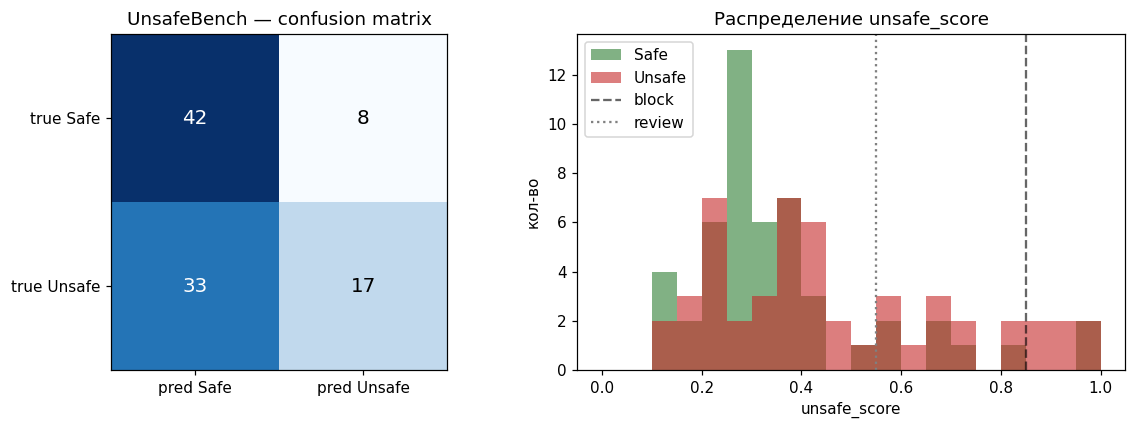

In [6]:
from sklearn.metrics import confusion_matrix

fig, ax = plt.subplots(1, 2, figsize=(11, 4))

# (1) Confusion matrix.
cm = confusion_matrix(df_ub["true_unsafe"], df_ub["flagged"], labels=[False, True])
im = ax[0].imshow(cm, cmap="Blues")
ax[0].set_xticks([0, 1]); ax[0].set_xticklabels(["pred Safe", "pred Unsafe"])
ax[0].set_yticks([0, 1]); ax[0].set_yticklabels(["true Safe", "true Unsafe"])
for (r, c), v in np.ndenumerate(cm):
    ax[0].text(c, r, str(v), ha="center", va="center",
               color="white" if v > cm.max() / 2 else "black", fontsize=13)
ax[0].set_title("UnsafeBench — confusion matrix")

# (2) Распределение unsafe_score: Safe vs Unsafe.
for val, color, name in [(False, "#2e7d32", "Safe"), (True, "#c62828", "Unsafe")]:
    sub = df_ub[df_ub["true_unsafe"] == val]["unsafe_score"]
    ax[1].hist(sub, bins=20, alpha=0.6, color=color, label=name, range=(0, 1))
ax[1].axvline(runner.settings.block_threshold, ls="--", color="black", alpha=0.6, label="block")
ax[1].axvline(runner.settings.review_threshold, ls=":", color="grey", label="review")
ax[1].set_xlabel("unsafe_score"); ax[1].set_ylabel("кол-во"); ax[1].legend()
ax[1].set_title("Распределение unsafe_score")
plt.tight_layout(); plt.show()

## 4. yesidobyte/nsfw1024 — recall (всё NSFW)

В наборе нет безопасных картинок → меряем долю пойманных (recall).

In [7]:
nsfw1024 = load_nsfw_stream("yesidobyte/nsfw1024", N_PER_DATASET)
df_n1 = run_images(nsfw1024, "nsfw1024") if nsfw1024 else pd.DataFrame()
if len(df_n1):
    recall_n1 = round(df_n1["flagged"].mean(), 3)
    print(f"nsfw1024: recall = {recall_n1}  (поймано {int(df_n1['flagged'].sum())}/{len(df_n1)})")

nsfw1024:   0%|          | 0/100 [00:00<?, ?img/s]

  [yesidobyte/nsfw1024] загружено 100 за 205s (попыток: 1)


classify · nsfw1024:   0%|          | 0/100 [00:00<?, ?img/s]

nsfw1024: recall = 0.99  (поймано 99/100)


## 5. wallstoneai/civitai-... — recall (всё NSFW, сгенерировано ИИ)

In [8]:
civitai = load_nsfw_stream("wallstoneai/civitai-top-nsfw-images-with-metadata", N_PER_DATASET)
df_cv = run_images(civitai, "civitai") if civitai else pd.DataFrame()
if len(df_cv):
    recall_cv = round(df_cv["flagged"].mean(), 3)
    print(f"civitai: recall = {recall_cv}  (поймано {int(df_cv['flagged'].sum())}/{len(df_cv)})")

civitai-top-nsfw-images-with:   0%|          | 0/100 [00:00<?, ?img/s]

Resolving data files:   0%|          | 0/6538 [00:00<?, ?it/s]

  [wallstoneai/civitai-top-nsfw-images-with-metadata] загружено 100 за 60s (попыток: 1)


classify · civitai:   0%|          | 0/100 [00:00<?, ?img/s]

civitai: recall = 0.93  (поймано 93/100)


## 6. Сводка и график

`recall` сравним по всем наборам; для UnsafeBench дополнительно есть FPR/precision
(там присутствуют безопасные картинки).

,dataset,n,recall,FPR,ROC_AUC
0,UnsafeBench,100,0.34,0.16,0.642
1,nsfw1024,100,0.99,NaN,NaN
2,civitai,100,0.93,NaN,NaN


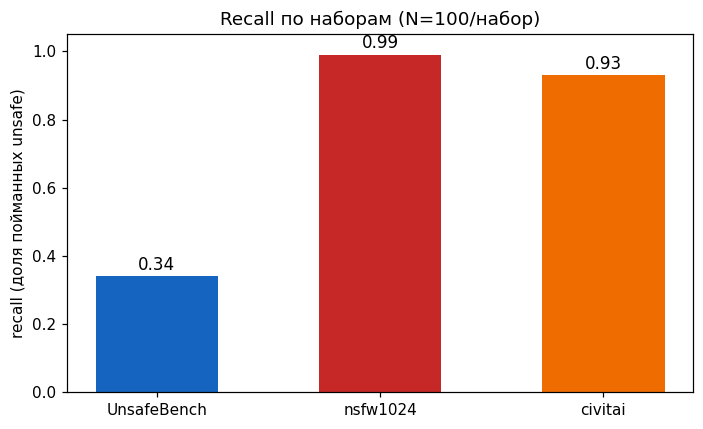

In [9]:
summary = []
summary.append({"dataset": "UnsafeBench", "n": m_ub["n"], "recall": m_ub["recall"],
                "FPR": m_ub["FPR"], "ROC_AUC": m_ub["ROC_AUC"]})
if len(df_n1):
    summary.append({"dataset": "nsfw1024", "n": len(df_n1),
                    "recall": round(df_n1["flagged"].mean(), 3), "FPR": np.nan, "ROC_AUC": np.nan})
if len(df_cv):
    summary.append({"dataset": "civitai", "n": len(df_cv),
                    "recall": round(df_cv["flagged"].mean(), 3), "FPR": np.nan, "ROC_AUC": np.nan})
summary_df = pd.DataFrame(summary)
display(summary_df)

fig, ax = plt.subplots(figsize=(6.5, 4))
x = np.arange(len(summary_df))
ax.bar(x, summary_df["recall"], 0.55, color=["#1565c0", "#c62828", "#ef6c00"][:len(x)])
for i, v in enumerate(summary_df["recall"]):
    ax.text(i, v + 0.02, f"{v:.2f}", ha="center", fontsize=11)
ax.set_xticks(x); ax.set_xticklabels(summary_df["dataset"])
ax.set_ylim(0, 1.05); ax.set_ylabel("recall (доля пойманных unsafe)")
ax.set_title(f"Recall по наборам (N={N_PER_DATASET}/набор)")
plt.tight_layout(); plt.show()

## Итог

- **UnsafeBench** даёт полную картину (precision/recall/FPR/AUC), т.к. содержит и Safe, и Unsafe.
- На **чистых NSFW-наборах** меряем только recall — модель ловит откровенный контент в
  основном через NSFW-детектор.
- Подкрути `N_PER_DATASET` сверху для большей выборки.